##1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from scipy import stats
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')

Jumlah baris  : 15,000
Jumlah kolom  : 30


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           15000 non-null

In [4]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [5]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print('Kolom dengan missing value:')
print(missing_pct.to_string())

Kolom dengan missing value:
coupon_code           40.886667
age                    8.000000
total_spent            7.000000
gender                 4.920000
satisfaction_score     4.680000


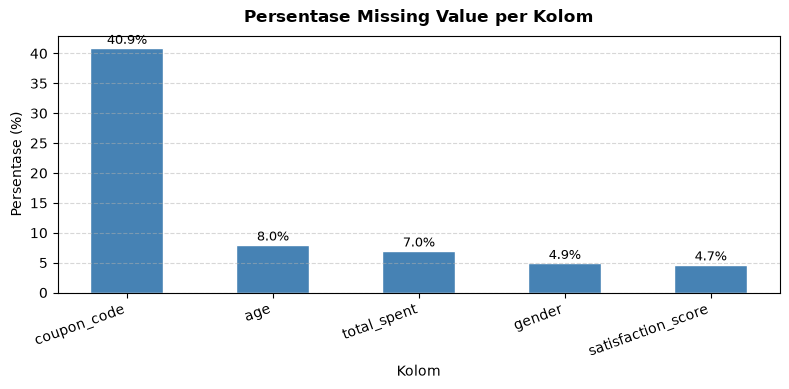

In [6]:
plt.figure(figsize=(8, 4))

plt.bar(missing_pct.index, missing_pct.values,
        color='steelblue', edgecolor='white', width=0.5)

plt.title('Persentase Missing Value per Kolom', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, val in enumerate(missing_pct.values):
    plt.text(i, val + 0.2, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

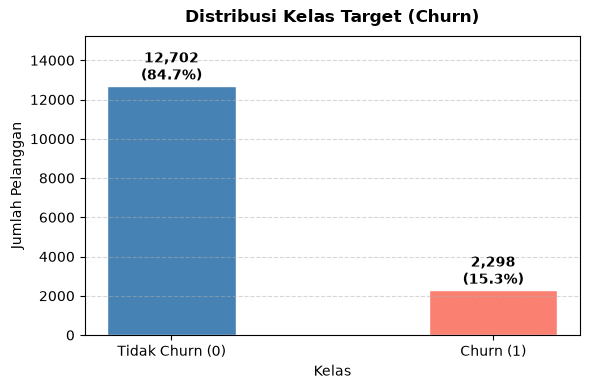

Tidak Churn (0) : 12,702 (84.7%)
Churn (1)       : 2,298 (15.3%)


In [7]:
churn_counts = df['churn'].value_counts()
labels = ['Tidak Churn (0)', 'Churn (1)']

plt.figure(figsize=(6, 4))

bars = plt.bar(labels, churn_counts.values,
               color=['steelblue', 'salmon'],
               edgecolor='white', width=0.4)

plt.title('Distribusi Kelas Target (Churn)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Kelas')
plt.ylabel('Jumlah Pelanggan')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, churn_counts.values):
    pct = val / len(df) * 100
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 80,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, churn_counts.max() * 1.2)
plt.tight_layout()
plt.show()

print(f'Tidak Churn (0) : {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)')
print(f'Churn (1)       : {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)')

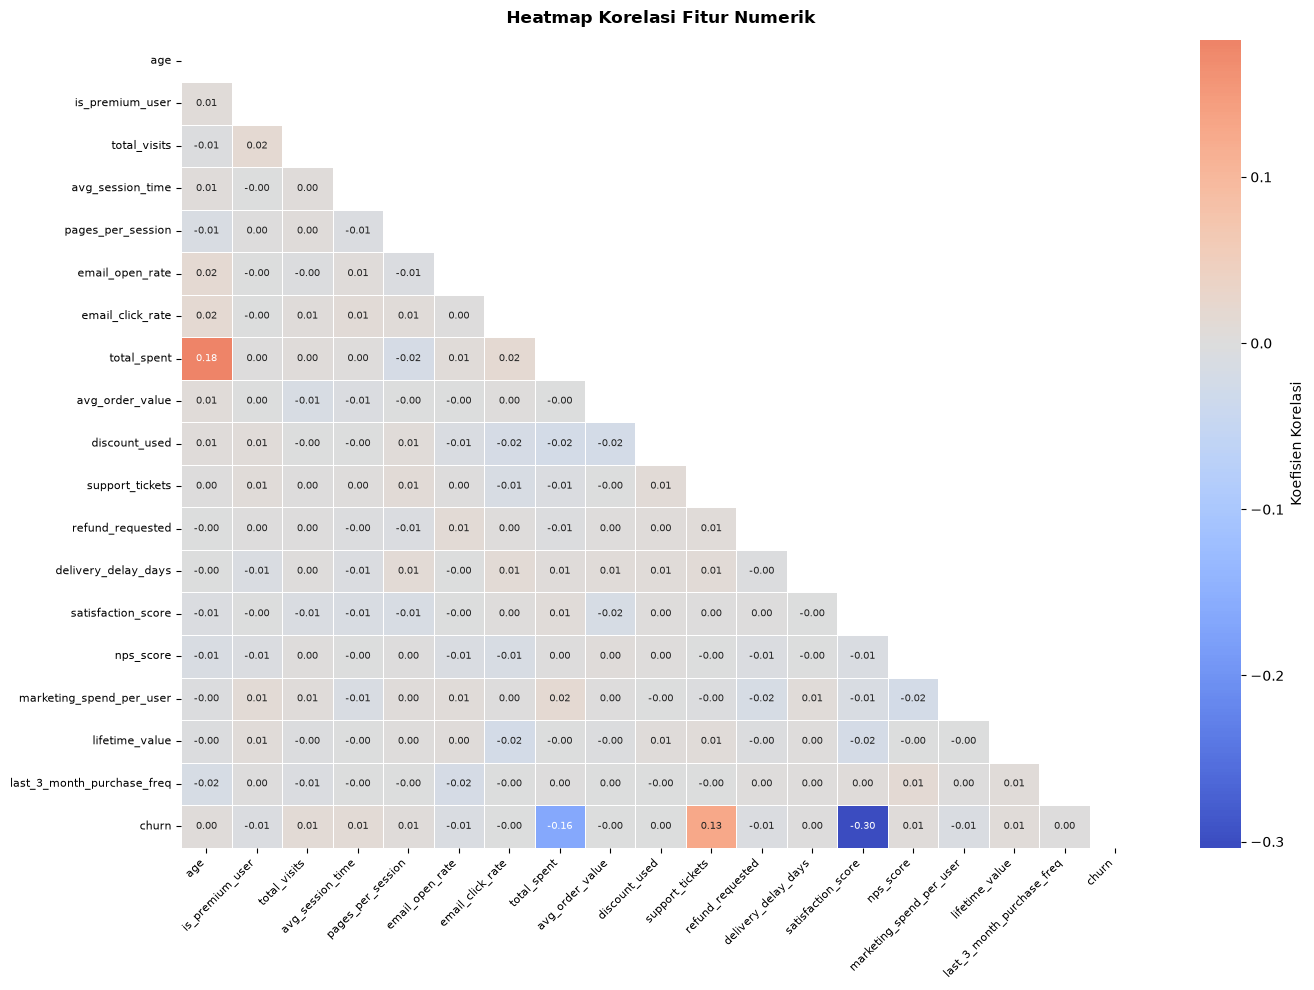

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'customer_id']

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Koefisien Korelasi'}
)

plt.title('Heatmap Korelasi Fitur Numerik', fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
corr_churn = corr['churn'].drop('churn').sort_values(ascending=False)
print('Korelasi fitur terhadap Churn:')
print(corr_churn.to_string())

Korelasi fitur terhadap Churn:
support_tickets               0.127910
total_visits                  0.013212
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588



# 2. Direct modeling


In [10]:
cols_to_drop = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']

X_direct = df.drop(columns=cols_to_drop + ['churn'])
y_direct = df['churn']

print(f"Shape X : {X_direct.shape}")
print(f"Shape y : {y_direct.shape}")
print(f"\nDistribusi target:\n{y_direct.value_counts()}")

Shape X : (15000, 25)
Shape y : (15000,)

Distribusi target:
churn
0    12702
1     2298
Name: count, dtype: int64


In [11]:
X_direct_enc = X_direct.copy()
cat_cols = X_direct_enc.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorikal yang di-encode: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    X_direct_enc[col] = X_direct_enc[col].astype(str)
    X_direct_enc[col] = le.fit_transform(X_direct_enc[col])

X_direct_enc = X_direct_enc.fillna(X_direct_enc.median(numeric_only=True))
print(f"\nShape setelah encode: {X_direct_enc.shape}")

Kolom kategorikal yang di-encode: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']

Shape setelah encode: (15000, 25)


In [12]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct_enc, y_direct,
    test_size=0.2,
    random_state=42,
    stratify=y_direct
)

print(f"Data latih : {X_train_d.shape[0]:,} baris")
print(f"Data uji   : {X_test_d.shape[0]:,} baris")

Data latih : 12,000 baris
Data uji   : 3,000 baris


In [13]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)

model_rf = RandomForestClassifier(random_state=42)

model_voting = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('svm', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

models_direct = {
    'Logistic Regression (Konvensional)': model_lr,
    'Random Forest (Ensemble Bagging)':    model_rf,
    'Voting Classifier (LR+SVM+KNN)':      model_voting
}


  Logistic Regression (Konvensional)
  Accuracy  : 0.8450
  Precision : 0.4815
  Recall    : 0.1413
  F1-Score  : 0.2185

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2540
           1       0.48      0.14      0.22       460

    accuracy                           0.84      3000
   macro avg       0.67      0.56      0.57      3000
weighted avg       0.80      0.84      0.81      3000



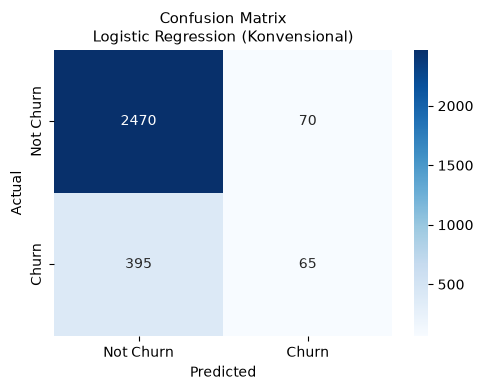


  Random Forest (Ensemble Bagging)
  Accuracy  : 0.8503
  Precision : 0.5175
  Recall    : 0.3543
  F1-Score  : 0.4206

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      2540
           1       0.52      0.35      0.42       460

    accuracy                           0.85      3000
   macro avg       0.70      0.65      0.67      3000
weighted avg       0.83      0.85      0.84      3000



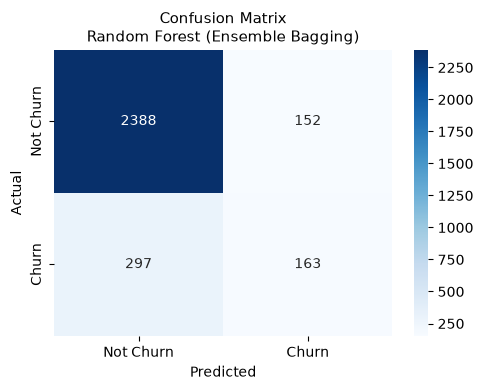


  Voting Classifier (LR+SVM+KNN)
  Accuracy  : 0.8487
  Precision : 0.6250
  Recall    : 0.0326
  F1-Score  : 0.0620

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2540
           1       0.62      0.03      0.06       460

    accuracy                           0.85      3000
   macro avg       0.74      0.51      0.49      3000
weighted avg       0.82      0.85      0.79      3000



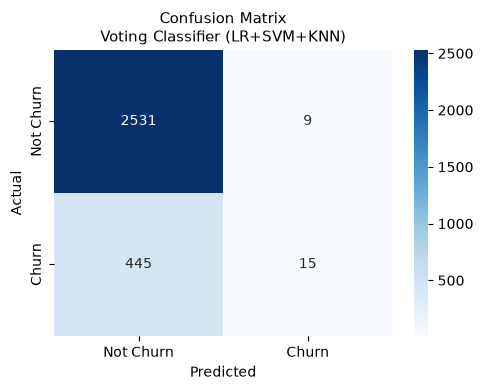

In [14]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, zero_division=0)}")

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'], ax=ax)
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

results_direct = []
for name, model in models_direct.items():
    result = evaluate_model(name, model, X_train_d, X_test_d, y_train_d, y_test_d)
    results_direct.append(result)


Ringkasan Performa — Direct Modeling
                                    Accuracy  Precision    Recall  F1-Score
Model                                                                      
Logistic Regression (Konvensional)  0.845000   0.481481  0.141304  0.218487
Random Forest (Ensemble Bagging)    0.850333   0.517460  0.354348  0.420645
Voting Classifier (LR+SVM+KNN)      0.848667   0.625000  0.032609  0.061983


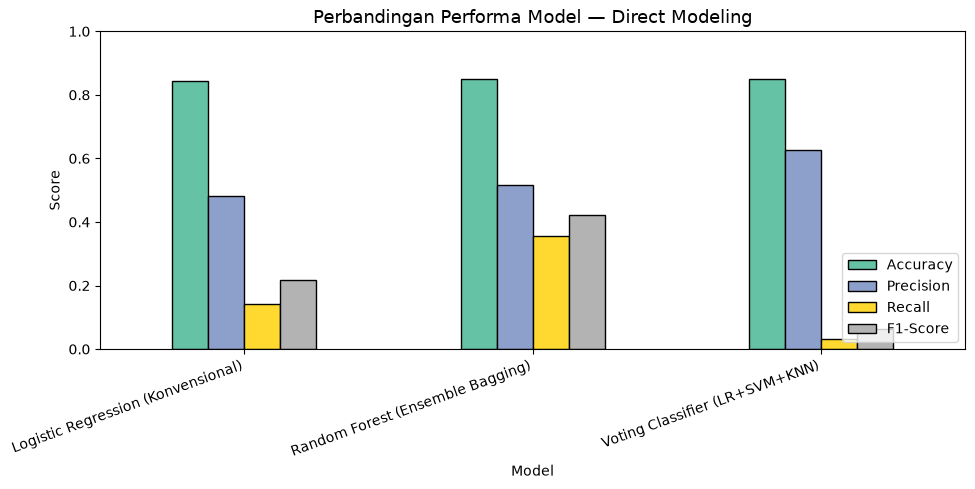

In [15]:
results_df_direct = pd.DataFrame(results_direct).set_index('Model')
print("\nRingkasan Performa — Direct Modeling")
print(results_df_direct.to_string())

results_df_direct.plot(kind='bar', figsize=(10, 5), ylim=(0, 1),
                       colormap='Set2', edgecolor='black')
plt.title('Perbandingan Performa Model — Direct Modeling', fontsize=13)
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Modeling Dengan Preprocessing

In [16]:
df_clean = df.copy()

print("Shape awal:", df_clean.shape)
print(f"\nMissing values:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")
print(f"\nDuplikasi: {df_clean.duplicated().sum()}")

Shape awal: (15000, 30)

Missing values:
gender                 738
age                   1200
total_spent           1050
coupon_code           6133
satisfaction_score     702
dtype: int64

Duplikasi: 0


In [17]:
df_clean = df_clean.drop_duplicates()
print(f"Shape setelah drop duplikasi: {df_clean.shape}")

Shape setelah drop duplikasi: (15000, 30)


In [18]:
cols_irrelevant = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
df_clean = df_clean.drop(columns=cols_irrelevant)
print(f"Shape setelah drop kolom tidak relevan: {df_clean.shape}")

Shape setelah drop kolom tidak relevan: (15000, 26)


In [19]:
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

if 'churn' in num_cols:
    num_cols.remove('churn')

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Total missing setelah imputasi: {df_clean.isnull().sum().sum()}")

Total missing setelah imputasi: 0


In [20]:
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f"Shape setelah outlier capping: {df_clean.shape}")

Shape setelah outlier capping: (15000, 26)


In [21]:
print(f"Kolom kategorikal: {cat_cols}")
for col in cat_cols:
    print(f"  {col}: {df_clean[col].nunique()} unique values → {df_clean[col].unique()[:5]}")

Kolom kategorikal: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']
  gender: 3 unique values → <ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
  country: 5 unique values → <ArrowStringArray>
['India', 'Germany', 'USA', 'UK', 'Bangladesh']
Length: 5, dtype: str
  city: 7 unique values → <ArrowStringArray>
['Berlin', 'Mumbai', 'London', 'Hamburg', 'New York']
Length: 5, dtype: str
  acquisition_channel: 5 unique values → <ArrowStringArray>
['Email', 'Organic', 'Facebook Ads', 'Referral', 'Google Ads']
Length: 5, dtype: str
  device_type: 3 unique values → <ArrowStringArray>
['Tablet', 'Desktop', 'Mobile']
Length: 3, dtype: str
  subscription_type: 2 unique values → <ArrowStringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
  payment_method: 5 unique values → <ArrowStringArray>
['UPI', 'BKash', 'PayPal', 'SEPA', 'Card']
Length: 5, dtype: str


In [22]:
binary_cats  = [col for col in cat_cols if df_clean[col].nunique() == 2]
nominal_cats = [col for col in cat_cols if df_clean[col].nunique() > 2]

print(f"Binary encode  : {binary_cats}")
print(f"One-Hot encode : {nominal_cats}")

for col in binary_cats:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))

df_clean = pd.get_dummies(df_clean, columns=nominal_cats, drop_first=True)

print(f"\nShape setelah encoding: {df_clean.shape}")
print(df_clean.dtypes.value_counts())

Binary encode  : ['subscription_type']
One-Hot encode : ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'payment_method']

Shape setelah encoding: (15000, 42)
bool       22
float64    10
int64      10
Name: count, dtype: int64


In [23]:
X_prep = df_clean.drop(columns=['churn'])
y_prep = df_clean['churn']

print(f"Shape X : {X_prep.shape}")
print(f"Shape y : {y_prep.shape}")
print(f"\nDistribusi target:\n{y_prep.value_counts()}")

Shape X : (15000, 41)
Shape y : (15000,)

Distribusi target:
churn
0    12702
1     2298
Name: count, dtype: int64


In [24]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep,
    test_size=0.2,
    random_state=42,
    stratify=y_prep
)

print(f"Data latih : {X_train_p.shape[0]:,} baris")
print(f"Data uji   : {X_test_p.shape[0]:,} baris")

Data latih : 12,000 baris
Data uji   : 3,000 baris


In [25]:
scaler = StandardScaler()

X_train_p_scaled = scaler.fit_transform(X_train_p)
X_test_p_scaled  = scaler.transform(X_test_p)

X_train_p_scaled = pd.DataFrame(X_train_p_scaled, columns=X_prep.columns)
X_test_p_scaled  = pd.DataFrame(X_test_p_scaled,  columns=X_prep.columns)

print("Scaling selesai.")
print(f"Mean train (sample): {X_train_p_scaled.mean().head(3).values}")

Scaling selesai.
Mean train (sample): [ 1.30266168e-17  2.30926389e-17 -8.28966525e-18]


In [26]:
model_lr_p = LogisticRegression(max_iter=1000, random_state=42)

model_rf_p = RandomForestClassifier(random_state=42)

model_voting_p = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('svm', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

models_prep = {
    'Logistic Regression (Konvensional)': model_lr_p,
    'Random Forest (Ensemble Bagging)':   model_rf_p,
    'Voting Classifier (LR+SVM+KNN)':     model_voting_p
}


  Logistic Regression (Konvensional)
  Accuracy  : 0.8447
  Precision : 0.4805
  Recall    : 0.1609
  F1-Score  : 0.2410

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2540
           1       0.48      0.16      0.24       460

    accuracy                           0.84      3000
   macro avg       0.67      0.56      0.58      3000
weighted avg       0.81      0.84      0.81      3000



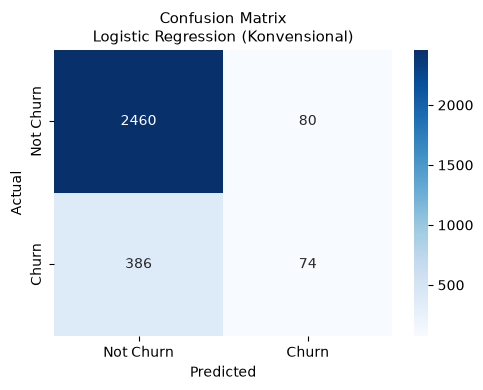


  Random Forest (Ensemble Bagging)
  Accuracy  : 0.8463
  Precision : 0.4975
  Recall    : 0.2152
  F1-Score  : 0.3005

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2540
           1       0.50      0.22      0.30       460

    accuracy                           0.85      3000
   macro avg       0.68      0.59      0.61      3000
weighted avg       0.81      0.85      0.82      3000



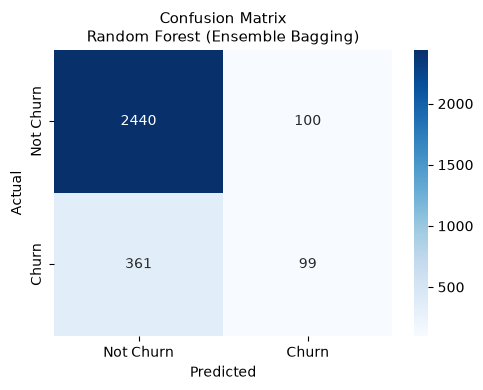


  Voting Classifier (LR+SVM+KNN)
  Accuracy  : 0.8457
  Precision : 0.4819
  Recall    : 0.0870
  F1-Score  : 0.1473

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2540
           1       0.48      0.09      0.15       460

    accuracy                           0.85      3000
   macro avg       0.67      0.54      0.53      3000
weighted avg       0.80      0.85      0.80      3000



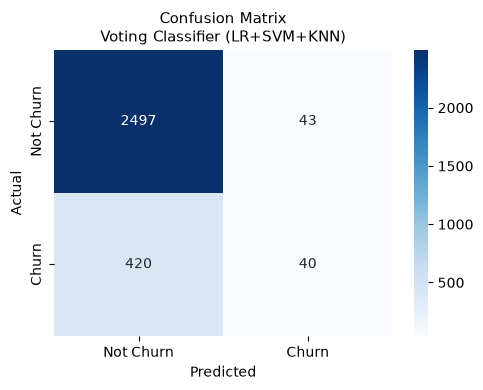

In [27]:
results_prep = []
for name, model in models_prep.items():
    result = evaluate_model(name, model,
                            X_train_p_scaled, X_test_p_scaled,
                            y_train_p, y_test_p)
    results_prep.append(result)


 Ringkasan Performa — Modeling dengan Preprocessing
                                    Accuracy  Precision    Recall  F1-Score
Model                                                                      
Logistic Regression (Konvensional)  0.844667   0.480519  0.160870  0.241042
Random Forest (Ensemble Bagging)    0.846333   0.497487  0.215217  0.300455
Voting Classifier (LR+SVM+KNN)      0.845667   0.481928  0.086957  0.147330


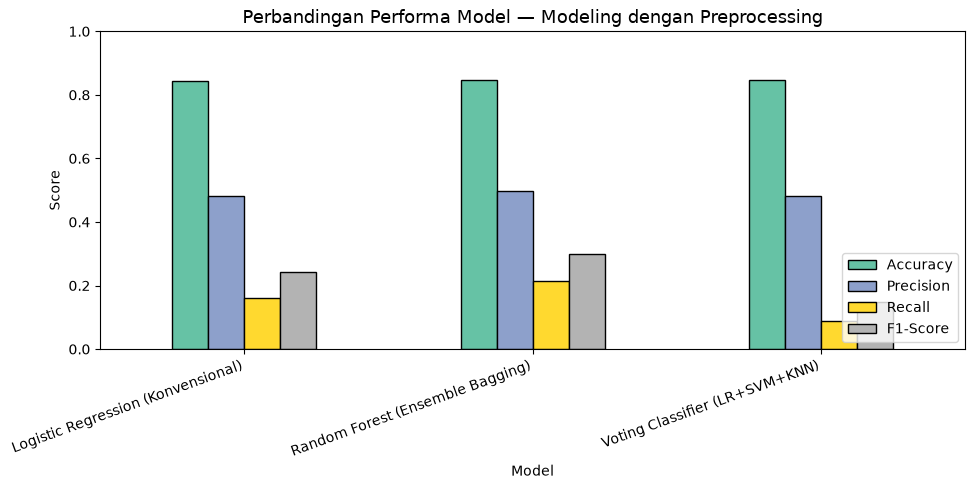

In [28]:
results_df_prep = pd.DataFrame(results_prep).set_index('Model')
print("\n Ringkasan Performa — Modeling dengan Preprocessing")
print(results_df_prep.to_string())

results_df_prep.plot(kind='bar', figsize=(10, 5), ylim=(0, 1),
                     colormap='Set2', edgecolor='black')
plt.title('Perbandingan Performa Model — Modeling dengan Preprocessing', fontsize=13)
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


 Perbandingan Direct vs Preprocessing (F1-Score)
                                      Direct  Preprocessing
Model                                                      
Logistic Regression (Konvensional)  0.218487       0.241042
Random Forest (Ensemble Bagging)    0.420645       0.300455
Voting Classifier (LR+SVM+KNN)      0.061983       0.147330


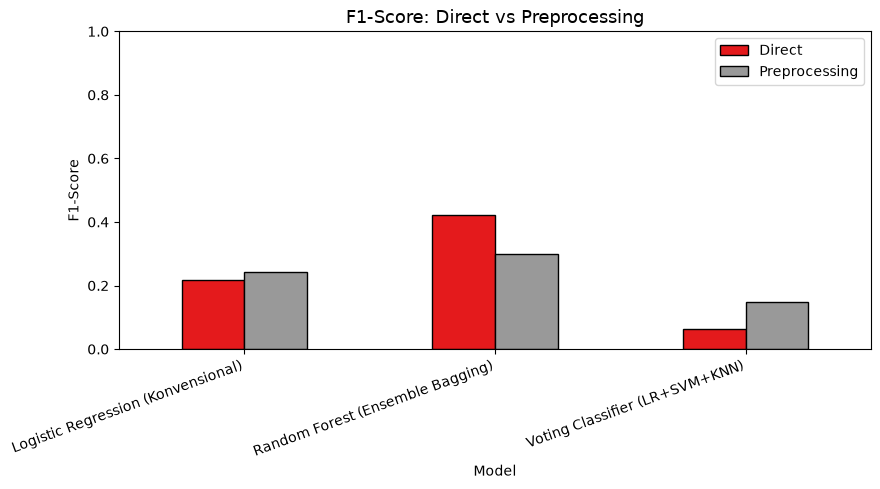

In [29]:
print("\n Perbandingan Direct vs Preprocessing (F1-Score)")
comparison = pd.DataFrame({
    'Direct':        results_df_direct['F1-Score'],
    'Preprocessing': results_df_prep['F1-Score']
})
print(comparison.to_string())

comparison.plot(kind='bar', figsize=(9, 5), ylim=(0, 1),
                colormap='Set1', edgecolor='black')
plt.title('F1-Score: Direct vs Preprocessing', fontsize=13)
plt.ylabel('F1-Score')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Hyperparameter Tuning & Feature Selection

 Top 15 Feature Importance:
total_spent                   0.192836
satisfaction_score            0.171543
support_tickets               0.069676
marketing_spend_per_user      0.044488
avg_session_time              0.043488
lifetime_value                0.043261
pages_per_session             0.042622
avg_order_value               0.042408
email_open_rate               0.038223
email_click_rate              0.036708
age                           0.034058
total_visits                  0.030260
last_3_month_purchase_freq    0.028529
nps_score                     0.025520
delivery_delay_days           0.021239


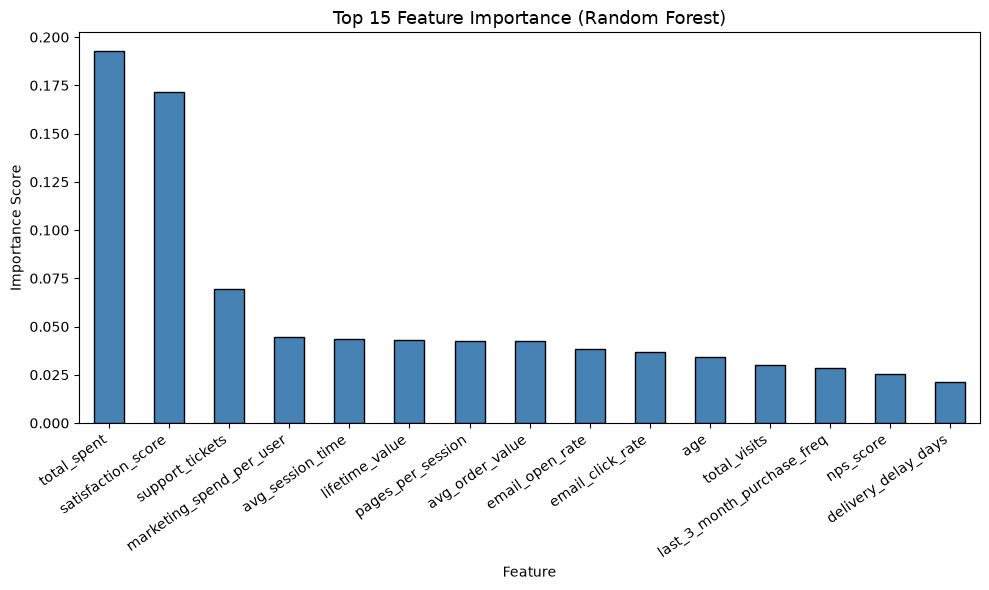

In [30]:
rf_for_importance = RandomForestClassifier(n_estimators=100, random_state=42)
rf_for_importance.fit(X_train_p_scaled, y_train_p)

importances = pd.Series(
    rf_for_importance.feature_importances_,
    index=X_prep.columns
).sort_values(ascending=False)

print(" Top 15 Feature Importance:")
print(importances.head(15).to_string())

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=13)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [31]:
THRESHOLD = 0.01  
selected_features = importances[importances >= THRESHOLD].index.tolist()

print(f"Jumlah fitur asli   : {X_prep.shape[1]}")
print(f"Jumlah fitur terpilih: {len(selected_features)}")
print(f"\nFitur terpilih:\n{selected_features}")

X_train_sel = X_train_p_scaled[selected_features]
X_test_sel  = X_test_p_scaled[selected_features]

Jumlah fitur asli   : 41
Jumlah fitur terpilih: 15

Fitur terpilih:
['total_spent', 'satisfaction_score', 'support_tickets', 'marketing_spend_per_user', 'avg_session_time', 'lifetime_value', 'pages_per_session', 'avg_order_value', 'email_open_rate', 'email_click_rate', 'age', 'total_visits', 'last_3_month_purchase_freq', 'nps_score', 'delivery_delay_days']


In [32]:
param_lr = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

param_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

param_voting = {
    'lr__C'             : [0.1, 1, 10],
    'lr__solver'        : ['lbfgs', 'liblinear'],
    'svm__C'            : [0.1, 1, 10],
    'svm__kernel'       : ['rbf', 'linear'],
    'knn__n_neighbors'  : [3, 5, 7, 11],
    'knn__weights'      : ['uniform', 'distance']
}

print("Parameter grid sudah disiapkan untuk ketiga model.")

Parameter grid sudah disiapkan untuk ketiga model.


In [33]:
CV_FOLDS  = 5
N_ITER    = 20
SCORING   = 'f1'
N_JOBS    = -1

print("Tuning Logistic Regression...")
rs_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_lr,
    n_iter=N_ITER, cv=CV_FOLDS, scoring=SCORING,
    random_state=42, n_jobs=N_JOBS, verbose=0
)
rs_lr.fit(X_train_sel, y_train_p)
print(f"  Best Params : {rs_lr.best_params_}")
print(f"  Best F1 CV  : {rs_lr.best_score_:.4f}")

Tuning Logistic Regression...
  Best Params : {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}
  Best F1 CV  : 0.2548


In [34]:
print("Tuning Random Forest...")
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=N_ITER, cv=CV_FOLDS, scoring=SCORING,
    random_state=42, n_jobs=N_JOBS, verbose=0
)
rs_rf.fit(X_train_sel, y_train_p)
print(f"  Best Params : {rs_rf.best_params_}")
print(f"  Best F1 CV  : {rs_rf.best_score_:.4f}")

Tuning Random Forest...
  Best Params : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
  Best F1 CV  : 0.4297


In [35]:
print("Tuning Voting Classifier...")

base_voting = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('svm', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

rs_voting = RandomizedSearchCV(
    base_voting,
    param_distributions=param_voting,
    n_iter=N_ITER, cv=CV_FOLDS, scoring=SCORING,
    random_state=42, n_jobs=N_JOBS, verbose=0
)
rs_voting.fit(X_train_sel, y_train_p)
print(f"  Best Params : {rs_voting.best_params_}")
print(f"  Best F1 CV  : {rs_voting.best_score_:.4f}")

Tuning Voting Classifier...
  Best Params : {'svm__kernel': 'rbf', 'svm__C': 0.1, 'lr__solver': 'liblinear', 'lr__C': 0.1, 'knn__weights': 'distance', 'knn__n_neighbors': 3}
  Best F1 CV  : 0.2368


In [36]:
best_models = {
    'Logistic Regression (Tuned)': rs_lr.best_estimator_,
    'Random Forest (Tuned)'      : rs_rf.best_estimator_,
    'Voting Classifier (Tuned)'  : rs_voting.best_estimator_
}

print("Best estimator dari setiap model sudah diperoleh.")
for name, mdl in best_models.items():
    print(f"  {name}: {mdl}")

Best estimator dari setiap model sudah diperoleh.
  Logistic Regression (Tuned): LogisticRegression(C=1, max_iter=1000, penalty='l2', random_state=42)
  Random Forest (Tuned): RandomForestClassifier(max_depth=20, max_features='log2', min_samples_leaf=2,
                       min_samples_split=5, random_state=42)
  Voting Classifier (Tuned): VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.1, max_iter=1000,
                                                 random_state=42,
                                                 solver='liblinear')),
                             ('svm',
                              SVC(C=0.1, probability=True, random_state=42)),
                             ('knn',
                              KNeighborsClassifier(n_neighbors=3,
                                                   weights='distance'))],
                 voting='soft')



  Logistic Regression (Tuned)
  Accuracy  : 0.8463
  Precision : 0.4966
  Recall    : 0.1587
  F1-Score  : 0.2405

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2540
           1       0.50      0.16      0.24       460

    accuracy                           0.85      3000
   macro avg       0.68      0.56      0.58      3000
weighted avg       0.81      0.85      0.81      3000



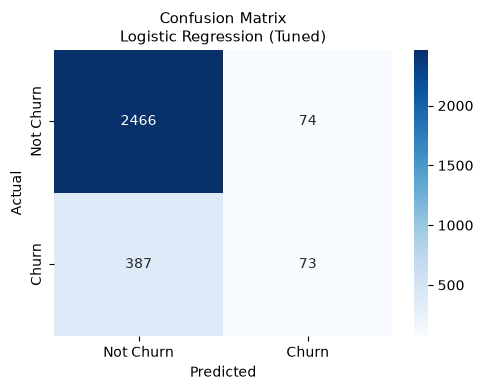


  Random Forest (Tuned)
  Accuracy  : 0.8553
  Precision : 0.5417
  Recall    : 0.3674
  F1-Score  : 0.4378

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      2540
           1       0.54      0.37      0.44       460

    accuracy                           0.86      3000
   macro avg       0.72      0.66      0.68      3000
weighted avg       0.84      0.86      0.84      3000



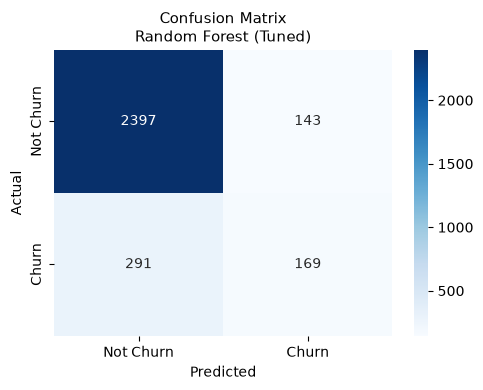


  Voting Classifier (Tuned)
  Accuracy  : 0.8500
  Precision : 0.5368
  Recall    : 0.1587
  F1-Score  : 0.2450

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2540
           1       0.54      0.16      0.24       460

    accuracy                           0.85      3000
   macro avg       0.70      0.57      0.58      3000
weighted avg       0.81      0.85      0.81      3000



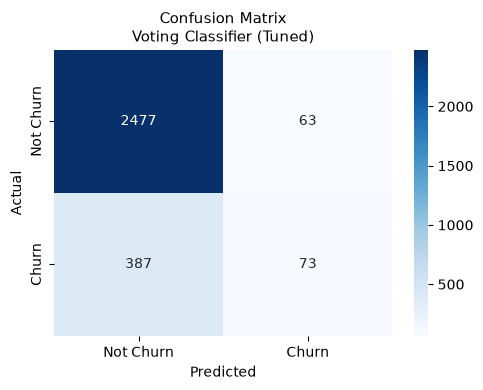

In [37]:
# --- 4.6 Evaluasi Model Tuned ---
results_tuned = []
for name, model in best_models.items():
    result = evaluate_model(name, model,
                            X_train_sel, X_test_sel,
                            y_train_p, y_test_p)
    results_tuned.append(result)


Ringkasan Performa — Hyperparameter Tuning
                             Accuracy  Precision    Recall  F1-Score
Model                                                               
Logistic Regression (Tuned)  0.846333   0.496599  0.158696  0.240527
Random Forest (Tuned)        0.855333   0.541667  0.367391  0.437824
Voting Classifier (Tuned)    0.850000   0.536765  0.158696  0.244966


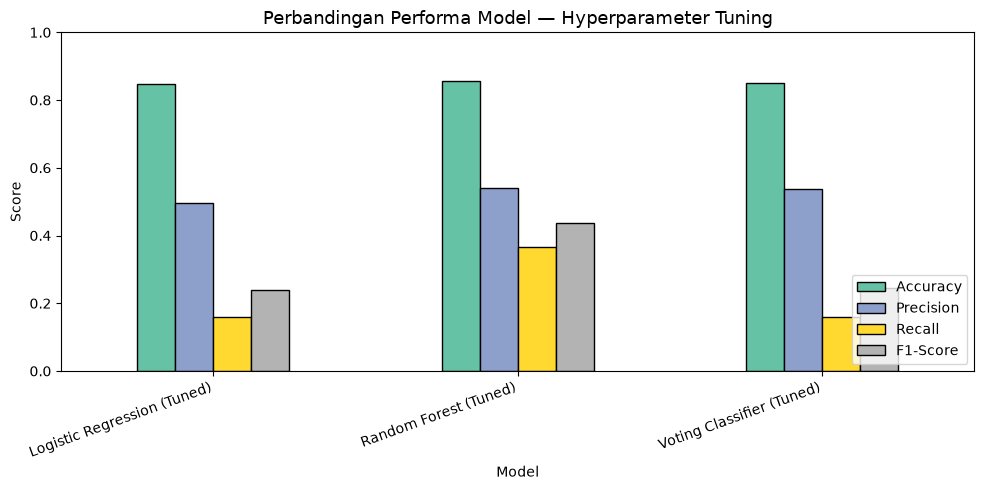

In [38]:
results_df_tuned = pd.DataFrame(results_tuned).set_index('Model')
print("\nRingkasan Performa — Hyperparameter Tuning")
print(results_df_tuned.to_string())

results_df_tuned.plot(kind='bar', figsize=(10, 5), ylim=(0, 1),
                      colormap='Set2', edgecolor='black')
plt.title('Perbandingan Performa Model — Hyperparameter Tuning', fontsize=13)
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Perbandingan F1-Score — Semua Skenario
                       Direct  Preprocessing     Tuned
Logistic Regression  0.218487       0.241042  0.240527
Random Forest        0.420645       0.300455  0.437824
Voting Classifier    0.061983       0.147330  0.244966


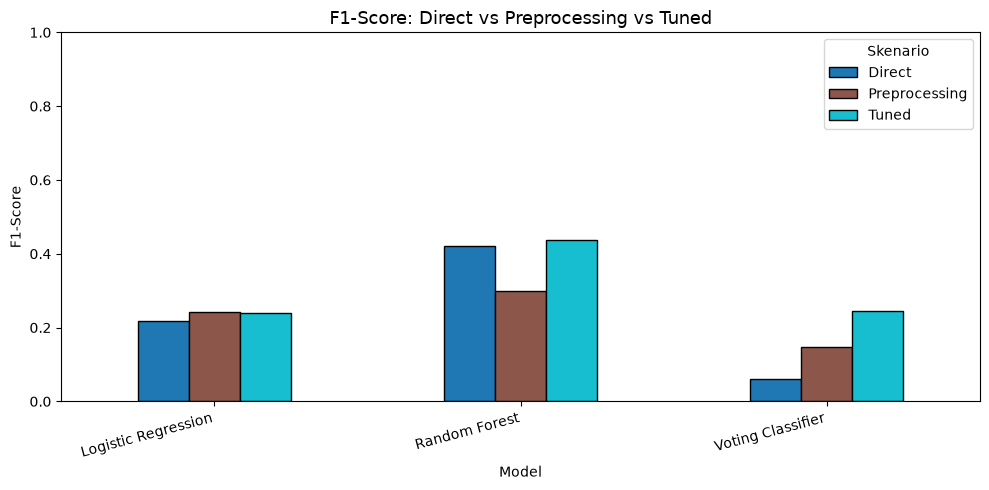

In [39]:
f1_comparison = pd.DataFrame({
    'Direct'        : results_df_direct['F1-Score'].values,
    'Preprocessing' : results_df_prep['F1-Score'].values,
    'Tuned'         : results_df_tuned['F1-Score'].values
}, index=['Logistic Regression', 'Random Forest', 'Voting Classifier'])

print("\nPerbandingan F1-Score — Semua Skenario")
print(f1_comparison.to_string())

f1_comparison.plot(kind='bar', figsize=(10, 5), ylim=(0, 1),
                   colormap='tab10', edgecolor='black')
plt.title('F1-Score: Direct vs Preprocessing vs Tuned', fontsize=13)
plt.ylabel('F1-Score')
plt.xlabel('Model')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Skenario')
plt.tight_layout()
plt.show()

In [40]:
all_results = pd.concat([
    results_df_direct.assign(Skenario='Direct'),
    results_df_prep.assign(Skenario='Preprocessing'),
    results_df_tuned.assign(Skenario='Tuned')
])

best_row = all_results.loc[all_results['F1-Score'].idxmax()]
print("\nMODEL TERBAIK KESELURUHAN:")
print(f"  Model    : {best_row.name}")
print(f"  Skenario : {best_row['Skenario']}")
print(f"  Accuracy : {best_row['Accuracy']:.4f}")
print(f"  Precision: {best_row['Precision']:.4f}")
print(f"  Recall   : {best_row['Recall']:.4f}")
print(f"  F1-Score : {best_row['F1-Score']:.4f}")


MODEL TERBAIK KESELURUHAN:
  Model    : Random Forest (Tuned)
  Skenario : Tuned
  Accuracy : 0.8553
  Precision: 0.5417
  Recall   : 0.3674
  F1-Score : 0.4378


In [41]:
import joblib

best_model_name = best_row.name

if 'Random Forest' in best_model_name:
    best_model_obj = rs_rf.best_estimator_
elif 'Logistic' in best_model_name:
    best_model_obj = rs_lr.best_estimator_
else:
    best_model_obj = rs_voting.best_estimator_

# Simpan model & scaler & selected features
joblib.dump(best_model_obj,   'best_model.pkl')
joblib.dump(scaler,           'scaler.pkl')
joblib.dump(selected_features,'selected_features.pkl')

print(f"Model terbaik disimpan: best_model.pkl")
print(f"Scaler disimpan       : scaler.pkl")
print(f"Fitur terpilih disimpan: selected_features.pkl")

Model terbaik disimpan: best_model.pkl
Scaler disimpan       : scaler.pkl
Fitur terpilih disimpan: selected_features.pkl


In [42]:
# ============================================================
# 5. DEPLOYMENT — Persiapan File
# ============================================================

In [43]:
import os

files_needed = ['best_model.pkl', 'scaler.pkl', 'selected_features.pkl']
for f in files_needed:
    status = "Ada" if os.path.exists(f) else " Tidak ditemukan"
    print(f"  {f}: {status}")

  best_model.pkl: Ada
  scaler.pkl: Ada
  selected_features.pkl: Ada


In [44]:
category_options = {}
cat_cols_original = ['gender', 'country', 'city', 'acquisition_channel',
                     'device_type', 'subscription_type', 'payment_method']

for col in cat_cols_original:
    if col in df.columns:
        category_options[col] = sorted(df[col].dropna().unique().tolist())

joblib.dump(category_options, 'category_options.pkl')
print("category_options.pkl disimpan")
print(f"   Kolom tersimpan: {list(category_options.keys())}")

category_options.pkl disimpan
   Kolom tersimpan: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']


In [45]:
joblib.dump(list(X_prep.columns), 'all_columns.pkl')
print("all_columns.pkl disimpan")
print(f"   Total kolom: {len(X_prep.columns)}")

all_columns.pkl disimpan
   Total kolom: 41


In [46]:
requirements = """streamlit==1.35.0
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.5.0
joblib==1.4.2
matplotlib==3.9.0
seaborn==0.13.2
plotly==5.22.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt dibuat")

requirements.txt dibuat


In [47]:
deploy_files = ['app.py', 'requirements.txt', 'best_model.pkl',
                'scaler.pkl', 'selected_features.pkl',
                'all_columns.pkl', 'category_options.pkl']

print("📁 Checklist File Deployment:")
for f in deploy_files:
    size   = os.path.getsize(f) / 1024 if os.path.exists(f) else 0
    status = f"({size:.1f} KB)" if os.path.exists(f) else "TIDAK ADA"
    print(f"  {f}: {status}")

print("\n🚀 Semua file siap untuk di-upload ke GitHub & deploy ke Streamlit Cloud!")

📁 Checklist File Deployment:
  app.py: (14.7 KB)
  requirements.txt: (0.1 KB)
  best_model.pkl: (9483.6 KB)
  scaler.pkl: (2.5 KB)
  selected_features.pkl: (0.3 KB)
  all_columns.pkl: (0.8 KB)
  category_options.pkl: (0.4 KB)

🚀 Semua file siap untuk di-upload ke GitHub & deploy ke Streamlit Cloud!
